# Data Exploration Notebook

Doel:
- Dataset verkennen
- Distributies bekijken
- Missing values analyseren
- Correlaties onderzoeken
- Eerste inzichten verzamelen

Imports:

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

Data laden:

In [20]:
df = pd.read_csv("../data/processed/btc_1h_features.csv")
df.head()

,open_time,open,high,low,close,volume,returns,hl_range,hl_pct,volatility,volatility_short,sma_20,sma_50,sma_ratio,rsi,macd,macd_signal,macd_histogram,bb_width,bb_position,volume_ratio,price_position
0,2020-01-03 01:00:00+00:00,6937.00,6946.07,6878.19,6888.85,2402.581684,-0.006941,67.88,0.985360,0.427184,0.397282,7054.6385,7146.4948,0.987147,21.042347,-66.001997,-52.522699,-13.479298,5.360872,0.051077,1.607106,0.028290
1,2020-01-03 02:00:00+00:00,6888.26,6966.80,6871.04,6956.88,2869.993553,0.009875,95.76,1.376479,0.487641,0.603310,7045.6840,7142.0920,0.986501,35.890784,-63.728919,-54.763943,-8.964976,5.329244,0.260474,1.789168,0.223565
2,2020-01-03 03:00:00+00:00,6957.66,6966.36,6940.00,6952.04,1246.589508,-0.000696,26.36,0.379169,0.479189,0.570754,7037.7575,7136.8074,0.986121,35.381000,-61.607859,-56.132726,-5.475132,5.383961,0.270990,0.784510,0.210959
3,2020-01-03 04:00:00+00:00,6952.04,7264.71,6948.64,7210.19,9560.897697,0.037133,316.07,4.383657,0.914916,1.644182,7040.5490,7136.1542,0.986603,64.414072,-38.650813,-52.636344,13.985531,5.422892,0.933864,4.753575,0.861508
4,2020-01-03 05:00:00+00:00,7210.20,7249.00,7168.48,7220.47,3575.770965,0.001426,80.52,1.115163,0.914925,1.624733,7043.4720,7136.0634,0.987025,65.086783,-19.404002,-45.989875,26.585874,5.656979,0.933330,1.664624,0.887622


Basic info:

In [21]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54318 entries, 0 to 54317
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   open_time         54318 non-null  object 
 1   open              54318 non-null  float64
 2   high              54318 non-null  float64
 3   low               54318 non-null  float64
 4   close             54318 non-null  float64
 5   volume            54318 non-null  float64
 6   returns           54318 non-null  float64
 7   hl_range          54318 non-null  float64
 8   hl_pct            54318 non-null  float64
 9   volatility        54318 non-null  float64
 10  volatility_short  54318 non-null  float64
 11  sma_20            54318 non-null  float64
 12  sma_50            54318 non-null  float64
 13  sma_ratio         54318 non-null  float64
 14  rsi               54318 non-null  float64
 15  macd              54318 non-null  float64
 16  macd_signal       54318 non-null  float6

,open,high,low,close,volume,returns,hl_range,hl_pct,volatility,volatility_short,sma_20,sma_50,sma_ratio,rsi,macd,macd_signal,macd_histogram,bb_width,bb_position,volume_ratio,price_position
count,54318.000000,54318.000000,54318.000000,54318.000000,54318.000000,54318.000000,54318.000000,54318.000000,54318.000000,54318.000000,54318.000000,54318.000000,54318.000000,54318.000000,54318.000000,54318.000000,54318.000000,54318.000000,54318.000000,54318.000000,54318.000000
mean,48225.336370,48414.974684,48026.945878,48226.576871,3012.517102,0.000066,388.028806,0.867749,0.554507,0.510240,48214.935214,48197.023434,1.000658,50.838085,8.431310,8.387167,0.044143,3.588034,0.513621,1.028912,0.533079
std,31440.815907,31529.588439,31348.921641,31440.516006,4401.112213,0.006669,401.989786,0.824634,0.371922,0.435651,31438.277325,31435.789306,0.015770,12.138557,346.868845,325.781689,106.443995,3.118105,0.335042,0.707450,0.268709
min,4131.230000,4610.000000,3782.130000,4130.640000,0.000000,-0.182115,0.000000,0.000000,0.045462,0.014287,4921.225500,5147.527200,0.809260,5.560567,-2527.269181,-2230.279803,-947.873491,0.170818,-0.563136,0.000000,0.000000
25%,22788.350000,22900.232500,22673.555000,22790.560000,814.562480,-0.002322,121.132500,0.406634,0.329212,0.246399,22850.801250,22846.640950,0.993832,43.087517,-104.528831,-101.379332,-38.209493,1.629773,0.263138,0.596462,0.302153
50%,41485.760000,41672.815000,41290.000000,41487.550000,1588.057374,0.000063,281.430000,0.652913,0.481144,0.398217,41520.114750,41430.741900,1.000557,50.785362,7.240885,7.051366,-0.368863,2.754966,0.525061,0.832526,0.541247
75%,67000.195000,67240.522500,66754.172500,67002.540000,3265.076437,0.002512,516.450000,1.060480,0.670354,0.640838,67022.283875,67033.566200,1.007614,58.510608,135.661089,131.454805,35.968213,4.518583,0.764387,1.215766,0.773596
max,126011.180000,126199.630000,125252.740000,126011.180000,137207.188600,0.173840,13112.690000,30.829643,7.451849,12.641949,124829.173500,124089.995800,1.094584,95.854267,2390.735922,1991.815458,884.889483,83.231750,1.575102,11.769601,1.000000


Missing values:

In [22]:
df.isna().sum()

open_time           0
open                0
high                0
low                 0
close               0
volume              0
returns             0
hl_range            0
hl_pct              0
volatility          0
volatility_short    0
sma_20              0
sma_50              0
sma_ratio           0
rsi                 0
macd                0
macd_signal         0
macd_histogram      0
bb_width            0
bb_position         0
volume_ratio        0
price_position      0
dtype: int64

In [23]:
df.dtypes


open_time            object
open                float64
high                float64
low                 float64
close               float64
volume              float64
returns             float64
hl_range            float64
hl_pct              float64
volatility          float64
volatility_short    float64
sma_20              float64
sma_50              float64
sma_ratio           float64
rsi                 float64
macd                float64
macd_signal         float64
macd_histogram      float64
bb_width            float64
bb_position         float64
volume_ratio        float64
price_position      float64
dtype: object

Distributies:

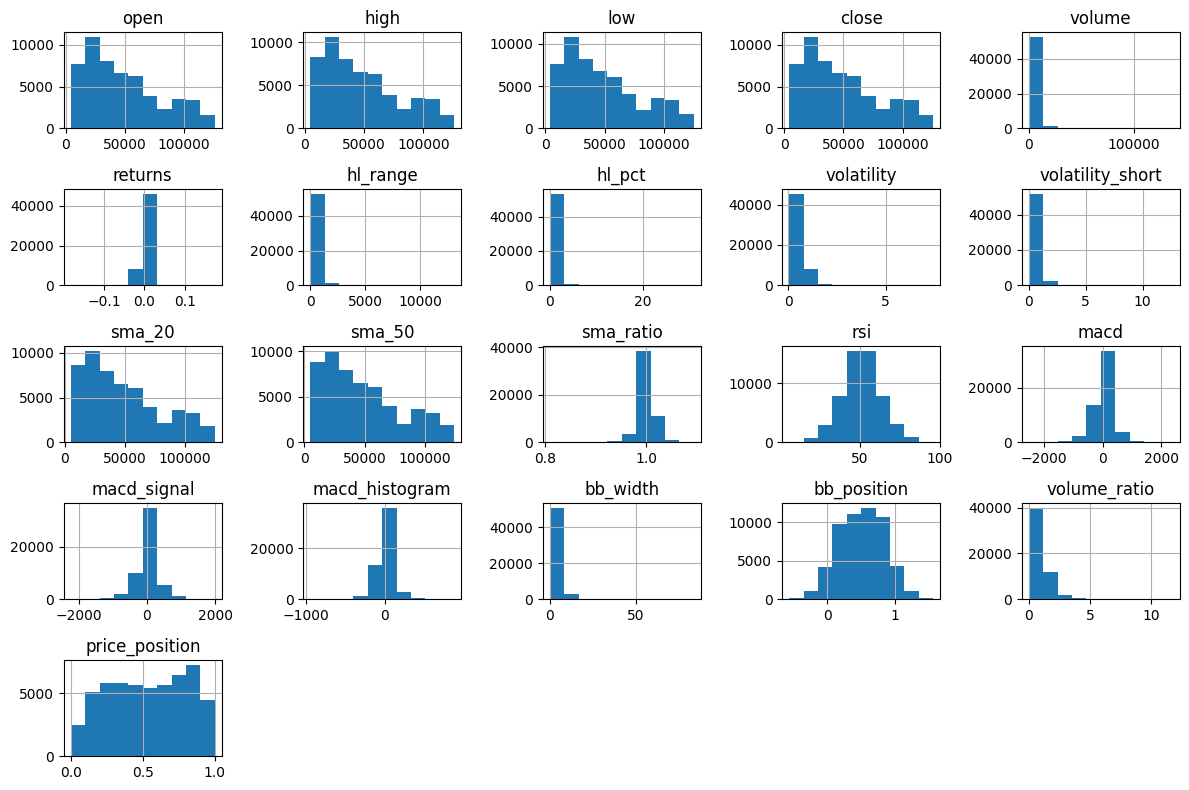

In [24]:
df.hist(figsize=(12, 8))
plt.tight_layout()
plt.show()

Correlaties:

In [25]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=False, cmap="coolwarm")
plt.show()

ValueError: could not convert string to float: '2020-01-03 01:00:00+00:00'

<Figure size 1000x800 with 0 Axes>

## Notes for Feature Engineering